In [2]:
import os
import torch
import torchvision

device = torch.device("cuda")

def torch_ds():
    input_resolution = 224
    data = "/data/ImageNet/"
    value_range = v2.Normalize(
        mean=[0.5] * 3,
        std=[0.5] * 3
    )
    
    val_dataset = datasets.ImageNet(
        data,
        split='val',
        transform=v2.Compose([
            v2.ToImage(),
            v2.Resize(256),
            v2.CenterCrop(input_resolution),
            v2.ToDtype(torch.float32, scale=True),
            value_range,
        ])
    )

    batch_size = 64

    val_loader = torch.utils.data.DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        num_workers=4, pin_memory=True, sampler=None,
        multiprocessing_context='spawn'
    )
    return val_loader

from simple_vit import SimpleVisionTransformer

class ViTGradCam(SimpleVisionTransformer):
    def forward(self, x: torch.Tensor):
        x = self._process_input(x)
        if self.pos_embedding is not None:
            x = x + self.pos_embedding
        if self.register:
            n = x.shape[0]
            x = torch.cat([torch.tile(self.reg, (n, 1, 1)), x], dim=1)
        x = self.encoder(x)
        if self.pool_type == 'tok':
            pooled = x[:, 0]
        else:
            pooled = x[:, self.register:]
            pooled = pooled.mean(dim = 1)
        logits = self.heads(pooled)
        return x, logits

hidden_dim = 384
input_resolution = 224
vit = ViTGradCam(
	image_size=input_resolution,
	patch_size=16,
	num_layers=12,
	num_heads=6,
	hidden_dim=hidden_dim,
	mlp_dim=hidden_dim * 4,
	representation_size=hidden_dim,
)

ep = 300
ROOT = "/media/jason-chou/T31/imagenet-runs/logs"
run = f"{ep}ep-Scion-2x-wd"
p = os.path.join(ROOT, run)

best_path = os.path.join(p, 'checkpoints/model_best.pth.tar')
ckpt = torch.load(best_path, weights_only=True)
state = ckpt['state_dict']

try:
    vit.load_state_dict(state)
except:
    vit.load_state_dict({k[len('module.'):]: v for k, v in state.items()})

In [3]:
def grad_cam(vit, images, target):
    tokens, logits = vit(images)
    tokens.retain_grad()
    target_logits = logits[torch.arange(logits.shape[0]), target]
    total = sum(target_logits)
    total.backward()
    token_grad = tokens.grad.mean(dim=1, keepdim=True)
    cam = token_grad * tokens
    cam = cam.sum(dim=2)
    return torch.clamp(cam, min=0.)

In [4]:
vit = vit.to(device)

In [5]:
import torchvision.datasets as datasets
from torchvision.transforms import v2

import matplotlib.pyplot as plt
import numpy as np
import cv2

# create heatmap from mask on image
def show_cam_on_image(img, mask):
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    cam = heatmap + np.float32(img)
    cam = cam / np.max(cam)
    return cam

data = "/data/ImageNet/"

value_range = v2.Normalize(
    mean=[0.5] * 3,
    std=[0.5] * 3
)

transform = v2.Compose([
    v2.ToImage(),
    v2.Resize(256),
    v2.CenterCrop(input_resolution),
    v2.ToDtype(torch.float32, scale=True),
    value_range,
])

val_dataset = datasets.ImageNet(
    data,
    split='val',
    transform=transform
)

first_25_classes = torch.utils.data.Subset(val_dataset, torch.arange(0, 1250, 50))
loader = torch.utils.data.DataLoader(
    first_25_classes, batch_size=25, shuffle=False,
    num_workers=1, pin_memory=True, sampler=None,
    multiprocessing_context='spawn'
)

In [6]:
scion_runs = []
for postfix in ['', '-0', '-1', '-2']:
    for ep in [30, 60, 90, 150, 300]:
        scion_runs.append(f"{ep}ep-Scion" + postfix)
        for f in [2, 3, 4]:
            scion_runs.append(f"{ep}ep-Scion-{f}x-wd" + postfix)

In [7]:
from scipy.stats import entropy
from tqdm.notebook import tqdm

def cam_entropy(vit, p, loader):
    best_path = os.path.join(p, 'checkpoints/model_best.pth.tar')
    ckpt = torch.load(best_path, weights_only=True)
    state = ckpt['state_dict']
    try:
        vit.load_state_dict(state)
    except:
        vit.load_state_dict({k[len('module.'):]: v for k, v in state.items()})
    result = []    
    for images, target in tqdm(loader):
        cam = grad_cam(vit, images.cuda(), target.cuda())
        result.append(entropy(cam.detach().cpu().numpy(), axis=1))
    return np.concatenate(result, dtype=np.float32)

def cam_entropy_sweep(root, vit, loader):
    entropy_file = 'cam_entropy.npy'
    for run in sorted(os.listdir(root)):
        if os.path.isdir(os.path.join(ROOT, run)) and (run in scion_runs or ('Scion' in run and 'lower-scale' in run)):
            p = os.path.join(root, run)
            if os.path.isdir(p):
                if os.path.exists(entropy_path := os.path.join(p, entropy_file)):
                    print(p + ' already done!')
                    continue
                else:
                    print(p)
                    ent = cam_entropy(vit, p, loader)
                    filename = entropy_file.split('.')[0]
                    np.save(os.path.join(p, filename), ent)    

cam_entropy_sweep("/media/jason-chou/T31/imagenet-runs/logs", vit, torch_ds())

/media/jason-chou/T31/imagenet-runs/logs/150ep-Scion


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/150ep-Scion-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/150ep-Scion-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/150ep-Scion-2x-wd


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/150ep-Scion-2x-wd-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/150ep-Scion-2x-wd-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/150ep-Scion-3x-wd


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/150ep-Scion-3x-wd-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/150ep-Scion-3x-wd-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/150ep-Scion-4x-wd


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/150ep-Scion-4x-wd-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/150ep-Scion-4x-wd-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/300ep-Scion


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/300ep-Scion-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/300ep-Scion-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/300ep-Scion-2x-wd


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/300ep-Scion-2x-wd-0.025-lower-scale-0


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/300ep-Scion-2x-wd-0.025-lower-scale-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/300ep-Scion-2x-wd-0.025-lower-scale-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/300ep-Scion-2x-wd-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/300ep-Scion-2x-wd-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/300ep-Scion-3x-wd


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/300ep-Scion-3x-wd-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/300ep-Scion-3x-wd-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/300ep-Scion-4x-wd


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/300ep-Scion-4x-wd-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/300ep-Scion-4x-wd-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/30ep-Scion


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/30ep-Scion-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/30ep-Scion-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/30ep-Scion-2x-wd


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/30ep-Scion-2x-wd-0.25-lower-scale-0


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/30ep-Scion-2x-wd-0.25-lower-scale-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/30ep-Scion-2x-wd-0.25-lower-scale-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/30ep-Scion-2x-wd-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/30ep-Scion-2x-wd-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/30ep-Scion-3x-wd


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/30ep-Scion-3x-wd-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/30ep-Scion-3x-wd-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/30ep-Scion-4x-wd


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/30ep-Scion-4x-wd-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/30ep-Scion-4x-wd-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/60ep-Scion


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/60ep-Scion-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/60ep-Scion-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/60ep-Scion-2x-wd


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/60ep-Scion-2x-wd-0.25-lower-scale-0


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/60ep-Scion-2x-wd-0.25-lower-scale-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/60ep-Scion-2x-wd-0.25-lower-scale-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/60ep-Scion-2x-wd-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/60ep-Scion-2x-wd-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/60ep-Scion-3x-wd


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/60ep-Scion-3x-wd-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/60ep-Scion-3x-wd-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/60ep-Scion-4x-wd


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/60ep-Scion-4x-wd-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/60ep-Scion-4x-wd-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/90ep-Scion


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/90ep-Scion-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/90ep-Scion-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/90ep-Scion-2x-wd


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/90ep-Scion-2x-wd-0.1-lower-scale-0


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/90ep-Scion-2x-wd-0.1-lower-scale-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/90ep-Scion-2x-wd-0.1-lower-scale-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/90ep-Scion-2x-wd-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/90ep-Scion-2x-wd-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/90ep-Scion-3x-wd


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/90ep-Scion-3x-wd-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/90ep-Scion-3x-wd-2


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/90ep-Scion-4x-wd


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/90ep-Scion-4x-wd-1


  0%|          | 0/782 [00:00<?, ?it/s]

/media/jason-chou/T31/imagenet-runs/logs/90ep-Scion-4x-wd-2


  0%|          | 0/782 [00:00<?, ?it/s]

In [11]:
ep = 300
ROOT = "/media/jason-chou/T31/imagenet-runs/logs"
run = f"{ep}ep-Scion-2x-wd"
p = os.path.join(ROOT, run)

best_path = os.path.join(p, 'checkpoints/model_best.pth.tar')
ckpt = torch.load(best_path, weights_only=True)
state = ckpt['state_dict']

try:
    vit.load_state_dict(state)
except:
    vit.load_state_dict({k[len('module.'):]: v for k, v in state.items()})

images, target = next(iter(loader))

images = images.cuda()
target = target.cuda()
cam = grad_cam(vit, images, target)
cam = cam.reshape(-1, 14, 14)

low, high = cam.amin(dim=(1, 2), keepdim=True), cam.amax(dim=(1, 2), keepdim=True)
cam_normalized = (cam - low) / (high - low)
cam_normalized = cam_normalized.detach()
original_images = (images / 2 + 0.5).detach()

fig, axs = plt.subplots(5, 5, figsize=(100, 100))

for i in range(5):
    for j in range(5):
        index = i * 5 + j
        image_transformer_attribution = original_images[index].permute(1, 2, 0).data.cpu().numpy()
        image_transformer_attribution = (image_transformer_attribution - image_transformer_attribution.min()) / (image_transformer_attribution.max() - image_transformer_attribution.min())
        
        vis = cam_normalized[index].reshape(1, 1, 14, 14)
        vis = torch.nn.functional.interpolate(vis, scale_factor=16, mode='bilinear')
        vis = vis.reshape(224, 224).data.cpu().numpy()
        
        vis = show_cam_on_image(image_transformer_attribution, vis)
        vis =  np.uint8(255 * vis)
        vis = cv2.cvtColor(np.array(vis), cv2.COLOR_RGB2BGR)
        axs[i, j].imshow(vis)
        axs[i, j].axis('off')

plt.savefig("scion_grad_cam_last_layer_first_25_classes.png")

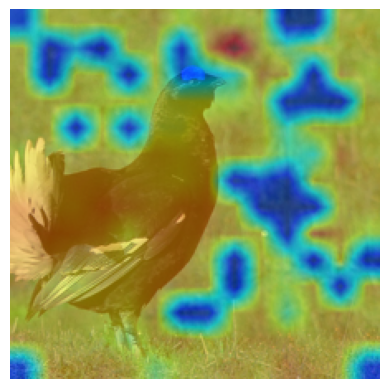

In [12]:
image, target = val_dataset[2000 * 2]  # 0-397 classes are animals!

image = image.cuda()
target = torch.tensor([target])
images = image.unsqueeze(0)
cam = grad_cam(vit, images, target)
cam = cam.reshape(-1, 14, 14)

low, high = cam.amin(dim=(1, 2), keepdim=True), cam.amax(dim=(1, 2), keepdim=True)
cam_normalized = (cam - low) / (high - low)
cam_normalized = cam_normalized.detach()
original_images = (images / 2 + 0.5).detach()

image_transformer_attribution = original_images[0].permute(1, 2, 0).data.cpu().numpy()
image_transformer_attribution = (image_transformer_attribution - image_transformer_attribution.min()) / (image_transformer_attribution.max() - image_transformer_attribution.min())

vis = cam_normalized[0].reshape(1, 1, 14, 14)
vis = torch.nn.functional.interpolate(vis, scale_factor=16, mode='bilinear')
vis = vis.reshape(224, 224).data.cpu().numpy()

vis = show_cam_on_image(image_transformer_attribution, vis)
vis = np.uint8(255 * vis)
vis = cv2.cvtColor(np.array(vis), cv2.COLOR_RGB2BGR)

plt.imshow(vis)
plt.axis('off')
plt.savefig("scion_grad_cam_last_layer_class_80_1st_image.png")